# Active Experimental Design v3 -- Early Stopping + LLM-Guided Acquisition

**Function**: Double Well  |  **Noise models**: Decaying & Heteroskedastic  |  **Budget**: 100

## What is new in v3?

| Feature | v2 | v3 |
|---------|-----|-----|
| Acquisition | GP uncertainty / cost | GP uncertainty / cost |
| Budget | Always exhausted | **Early stop when uncertainty < threshold** |
| Decision maker | Formula only | **Optional: Gemini LLM reasons about next point** |
| Diversity | Exponential repulsion | Same + LLM context awareness |

## Two strategies compared
- **GP + Early Stop**: Pure formula-based, halts when `max_std < 0.05`
- **LLM-Guided**: Gemini reads the uncertainty map and suggests `(x, t)` each step

Set `GEMINI_API_KEY` in Cell 3 to enable LLM mode. Leave empty to run GP-only.


In [ ]:
import importlib, subprocess, sys

def ensure(pkg, import_name=None):
    name = import_name or pkg
    if importlib.util.find_spec(name) is None:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
    else:
        print(f'{pkg} already installed.')

packages = [
    ('numpy',            'numpy'),
    ('matplotlib',       'matplotlib'),
    ('seaborn',          'seaborn'),
    ('scipy',            'scipy'),
    ('torch',            'torch'),
    ('gpytorch',         'gpytorch'),
    ('google-genai',     'google.genai'),
]
for pkg, imp in packages:
    ensure(pkg, imp)
print('All packages ready.')


numpy already installed.
matplotlib already installed.
seaborn already installed.
scipy already installed.
torch already installed.
Installing gpytorch...
google-genai already installed.
All packages ready.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns
import torch
import gpytorch
import json, re, warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'legend.fontsize':   9,
    'figure.dpi':        130,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
})

C_DECAY = '#00BCD4'
C_HET   = '#FF5722'
C_LLM   = '#7C4DFF'
NOISE_COLORS  = {'decay': C_DECAY, 'heteroskedastic': C_HET}
NOISE_LABELS  = {'decay': 'Decaying Noise', 'heteroskedastic': 'Heteroskedastic Noise'}
NOISE_TYPES   = ['decay', 'heteroskedastic']
print('Imports done.')


Imports done.


In [ ]:
# ============================================================
#  GEMINI API KEY SETUP
#  Get your free key at: https://aistudio.google.com/app/apikey
#  Leave empty ('') to run in GP-only mode (no LLM).
# ============================================================

GEMINI_API_KEY = ''   # <-- paste your Gemini API key here

# Initialise Gemini client
gemini_client = None
if GEMINI_API_KEY:
    try:
        from google import genai
        gemini_client = genai.Client(api_key=GEMINI_API_KEY)
        print('Gemini client ready -- LLM-guided mode ENABLED')
    except Exception as e:
        print(f'Gemini init failed: {e}  -- falling back to GP-only')
        gemini_client = None
else:
    print('No API key -- LLM-guided mode DISABLED, GP-only mode will run')


Gemini client ready -- LLM-guided mode ENABLED


In [ ]:
# ============================================================
#  GROUND TRUTH: DOUBLE WELL  (fixed normalisation)
# ============================================================

_X_DOMAIN = np.linspace(-4, 4, 2000)
_DW_RAW   = 0.08*(_X_DOMAIN**2-4)**2 + 0.15*_X_DOMAIN
_DW_MAX   = _DW_RAW.max()

def double_well(x):
    x = np.asarray(x, dtype=float)
    return (0.08*(x**2 - 4)**2 + 0.15*x) / _DW_MAX

# ============================================================
#  NOISE MODELS
# ============================================================

def noise_decay_floor(x=None, t=None, sigma_min=0.05, A=0.18, tau=1.0):
    return sigma_min + A * np.exp(-np.asarray(t) / tau)

def make_heteroskedastic_noise_model(f, xlim, n_grid=200, smooth_window=3):
    xmin, xmax = xlim
    x_grid = np.linspace(xmin, xmax, n_grid)
    grad   = np.abs(np.gradient(f(x_grid), x_grid, edge_order=2))
    if smooth_window > 1:
        kernel = np.ones(smooth_window) / smooth_window
        half   = smooth_window // 2
        grad   = np.convolve(np.pad(grad, half, mode='reflect'), kernel, mode='valid')
    scale          = np.percentile(grad, 95) + 1e-12
    grad_norm_grid = grad / scale
    def noise_model(x, t, sigma_min=0.05, sigma_max=0.5, tau=1.5):
        x, t = np.asarray(x, float), np.asarray(t, float)
        g        = np.interp(x, x_grid, grad_norm_grid)
        sigma0_x = sigma_min + (sigma_max - sigma_min) * g
        return sigma_min + (sigma0_x - sigma_min) * np.exp(-t / tau)
    noise_model.grad_norm_grid = grad_norm_grid
    noise_model.x_grid         = x_grid
    return noise_model

noise_het = make_heteroskedastic_noise_model(double_well, (-4, 4))

NOISE_MODELS = {
    'decay':           noise_decay_floor,
    'heteroskedastic': noise_het,
}
print('Ground truth and noise models ready.')


Ground truth and noise models ready.


In [ ]:
# ============================================================
#  MEASUREMENT SIMULATOR
# ============================================================

class MeasurementSimulator:
    def __init__(self, f, noise_model, rng=None):
        self.f = f; self.noise_model = noise_model
        self.rng = (np.random.default_rng(rng)
                    if isinstance(rng, (int, type(None))) else rng)
    def measure(self, coords):
        coords = np.asarray(coords, float)
        x, t   = coords[:,0], coords[:,1]
        sigma  = np.asarray(self.noise_model(x, t), float)
        return self.f(x) + self.rng.normal(0, sigma, size=len(x))
    __call__ = measure

# ============================================================
#  GAUSSIAN PROCESS SURROGATE
# ============================================================

def gp_predict(x_train, y_train, x_test, training_iter=200, lr=0.05):
    to_t = lambda a: torch.as_tensor(a, dtype=torch.float32)
    x_tr = to_t(x_train).unsqueeze(-1)
    y_tr = to_t(y_train)
    x_te = to_t(x_test ).unsqueeze(-1)

    lik = gpytorch.likelihoods.GaussianLikelihood()

    class GP(gpytorch.models.ExactGP):
        def __init__(self, tx, ty, lk):
            super().__init__(tx, ty, lk)
            self.mean_module  = gpytorch.means.ConstantMean()
            self.covar_module = gpytorch.kernels.ScaleKernel(
                gpytorch.kernels.RBFKernel())
        def forward(self, x):
            return gpytorch.distributions.MultivariateNormal(
                self.mean_module(x), self.covar_module(x))

    model = GP(x_tr, y_tr, lik)
    model.covar_module.base_kernel.lengthscale = 0.8
    model.covar_module.outputscale             = 0.3
    lik.noise                                  = 0.01
    model.train(); lik.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    mll = gpytorch.mlls.ExactMarginalLogLikelihood(lik, model)
    for _ in range(200):
        opt.zero_grad()
        loss = -mll(model(x_tr), y_tr)
        loss.backward(); opt.step()

    model.eval(); lik.eval()
    with torch.no_grad():
        pred = lik(model(x_te))
        return pred.mean.numpy(), pred.stddev.numpy()

print('Simulator and GP ready.')


Simulator and GP ready.


In [ ]:
def travel_cost(dx, speed=0.5):
    return abs(dx) / speed

def optimal_t(noise_type, xc, budget_after_travel,
              grad_x_grid=None, grad_norm_grid=None):
    min_t = 0.05
    if noise_type == 'decay':
        t_opt = 3.0
    elif noise_type == 'heteroskedastic':
        if grad_norm_grid is not None:
            g     = float(np.interp(xc, grad_x_grid, grad_norm_grid))
            t_opt = 1.0 + 3.0 * g
        else:
            t_opt = 2.5
    else:
        t_opt = 1.0
    return max(min_t, min(t_opt, budget_after_travel))

print('Cost model ready.')


Cost model ready.


In [ ]:
# ============================================================
#  LLM ACQUISITION HELPER (Gemini)
# ============================================================

def llm_suggest_next_point(client, model_name,
                            x_obs, y_obs,
                            x_current, budget_left,
                            x_grid, gp_std,
                            noise_type):
    # Build uncertainty summary: top 8 most uncertain positions
    top_idx   = np.argsort(gp_std)[::-1][:8]
    unc_lines = [f'  x={x_grid[i]:.2f}, std={gp_std[i]:.3f}' for i in top_idx]
    obs_repr  = [f'{v:.2f}' for v in x_obs[-6:]]

    prompt = (
        'You are an expert in active experimental design for scientific discovery.\n\n'
        'TASK: Discover an unknown function f(x) on x in [-4.0, 4.0] by choosing'
        ' where to probe and for how long, under a time budget.\n'
        'The function value is approximately in range [-0.3, 1.0].\n\n'
        f'Current state:\n'
        f'  Measurements taken so far: {len(x_obs)}\n'
        f'  Recent measurement positions (last 6): {obs_repr}\n'
        f'  Current probe position: x = {x_current:.2f}\n'
        f'  Budget remaining: {budget_left:.1f} seconds\n'
        f'  Noise model: {noise_type}\n\n'
        'Regions with highest GP uncertainty (most informative to measure):\n'
        + '\n'.join(unc_lines) + '\n\n'
        'Physics of the instrument:\n'
        '  Travel speed = 0.5 units/second\n'
        '  Travel cost  = |x_next - x_current| / 0.5  seconds\n'
        f'  Recommended measurement duration: {3.0 if noise_type == "decay" else 2.0} s\n'
        '  Min duration: 0.05 s,  Max: 5.0 s\n\n'
        'Choose the SINGLE best next measurement location and duration.\n'
        'Balance: high uncertainty vs low travel cost vs budget remaining.\n'
        'If most uncertainty is low (< 0.05), choose x_next = null to signal stop.\n\n'
        'Respond ONLY with valid JSON (no markdown, no extra text):\n'
        '{"x": <float or null>, "t": <float>, "reasoning": "<one short sentence>"}'
    )

    try:
        from google import genai
        response = client.models.generate_content(model=model_name, contents=prompt)
        text = response.text.strip()
        # Strip markdown code fences if present
        text = re.sub(r'^```[a-z]*\n?', '', text)
        text = re.sub(r'\n?```$',       '', text)
        m = re.search(r'\{.*\}', text, re.DOTALL)
        if m:
            data = json.loads(m.group())
            x_raw = data.get('x')
            if x_raw is None:
                return None, None, data.get('reasoning', 'LLM says stop')
            x_next = float(np.clip(float(x_raw), -4.0, 4.0))
            t_next = float(np.clip(float(data.get('t', 2.0)), 0.05, 5.0))
            return x_next, t_next, str(data.get('reasoning', ''))
    except Exception as exc:
        print(f'  [LLM error: {exc}]')
    return None, None, 'parse_error'

print('LLM helper ready.')


LLM helper ready.


In [ ]:
# ============================================================
#  V3 ACTIVE LEARNING LOOP
#  mode='gp'  : GP uncertainty / cost + early stopping
#  mode='llm' : Gemini LLM suggests next (x,t) + early stopping
# ============================================================

STOP_THRESHOLD = 0.05   # stop when max GP std drops below this
MIN_STEPS      = 8      # always take at least this many adaptive steps
DIVERSITY_SIGMA = 0.4
DIVERSITY_W     = 0.8
LLM_MODEL       = 'gemini-2.0-flash'

def run_v3(
        noise_type, noise_model, budget=100,
        x_min=-4.0, x_max=4.0, x0=0.0,
        n_init=5, n_candidates=120, rng_seed=42,
        mode='gp', client=None):

    rng    = np.random.default_rng(rng_seed)
    x_grid = np.linspace(x_min, x_max, 400)
    cands  = np.linspace(x_min, x_max, n_candidates)
    gnorm  = getattr(noise_model, 'grad_norm_grid', None)
    gxg    = getattr(noise_model, 'x_grid',         None)
    sim    = MeasurementSimulator(double_well, noise_model, rng=rng)

    x_obs, y_obs, t_obs, cost_log = [], [], [], []
    llm_log = []   # stores LLM reasoning at each step
    pos = float(x0)
    rem = float(budget)
    adaptive_step = 0
    stopped_early = False

    # ---- Phase 1: warm-start with evenly-spaced points ----
    for xi in np.linspace(x_min, x_max, n_init):
        init_t = 1.0
        tc     = travel_cost(xi - pos)
        if rem - tc - init_t < 1.0:
            break
        y = sim.measure(np.array([[xi, init_t]]))[0]
        x_obs.append(xi); y_obs.append(y); t_obs.append(init_t)
        rem -= (tc + init_t)
        cost_log.append({'step': len(cost_log), 'x': xi, 't': init_t,
                         'travel': tc, 'budget_left': rem, 'phase': 'init',
                         'source': 'init'})
        pos = xi

    # ---- Phase 2: adaptive loop ----------------------------
    while rem > 0.5:
        try:
            _, sg = gp_predict(np.array(x_obs), np.array(y_obs), x_grid)
        except Exception:
            break

        # ---- Early stopping check ----
        if adaptive_step >= MIN_STEPS and sg.max() < STOP_THRESHOLD:
            stopped_early = True
            print(f'  Early stop at step {adaptive_step}: max_std={sg.max():.4f} < {STOP_THRESHOLD}')
            break

        # ---- Choose next point ----
        if mode == 'llm' and client is not None:
            x_next, t_next, reasoning = llm_suggest_next_point(
                client, LLM_MODEL,
                x_obs, y_obs, pos, rem,
                x_grid, sg, noise_type)
            if x_next is None:
                stopped_early = True
                print(f'  LLM requested stop at step {adaptive_step}: {reasoning}')
                break
            # Validate travel cost is affordable
            tc_llm = travel_cost(x_next - pos)
            if rem - tc_llm < 0.05:
                stopped_early = True; break
            t_next = min(t_next, rem - tc_llm)
            llm_log.append({'step': adaptive_step, 'x': x_next,
                             't': t_next, 'reasoning': reasoning})
            best_x, best_t, source = x_next, t_next, 'llm'
        else:
            # GP acquisition: uncertainty / cost + diversity penalty
            best_s, best_x, best_t = -float('inf'), None, None
            x_obs_arr = np.array(x_obs)
            for xc in cands:
                tc   = travel_cost(xc - pos)
                r2   = rem - tc
                if r2 < 0.05:
                    continue
                to   = optimal_t(noise_type, xc, r2, gxg, gnorm)
                cost = tc + to
                gp_score = float(np.interp(xc, x_grid, sg)) / cost
                min_dist  = np.min(np.abs(x_obs_arr - xc)) if len(x_obs_arr) else 8.0
                diversity = 1.0 - np.exp(-min_dist / DIVERSITY_SIGMA)
                s = gp_score * (1.0 - DIVERSITY_W + DIVERSITY_W * diversity)
                if s > best_s:
                    best_s, best_x, best_t = s, xc, to
            if best_x is None:
                break
            source = 'gp'

        tc     = travel_cost(best_x - pos)
        best_t = min(best_t, rem - tc)
        if best_t < 0.05:
            break

        y = sim.measure(np.array([[best_x, best_t]]))[0]
        x_obs.append(best_x); y_obs.append(y); t_obs.append(best_t)
        rem -= (tc + best_t)
        cost_log.append({'step': len(cost_log), 'x': best_x, 't': best_t,
                         'travel': tc, 'budget_left': rem,
                         'phase': 'adaptive', 'source': source})
        pos = best_x
        adaptive_step += 1

    xa, ya, ta = map(np.array, [x_obs, y_obs, t_obs])
    gm, gs     = gp_predict(xa, ya, x_grid)
    tv         = double_well(x_grid)
    rmse       = np.sqrt(np.mean((gm - tv)**2))

    return dict(noise_type=noise_type, mode=mode,
                x_obs=xa, y_obs=ya, t_obs=ta,
                x_grid=x_grid, gp_mean=gm, gp_std=gs,
                true=tv, rmse=rmse, cost_log=cost_log,
                llm_log=llm_log,
                budget_used=budget - rem, n_meas=len(x_obs),
                stopped_early=stopped_early)

print('V3 active learning loop ready.')


V3 active learning loop ready.


In [ ]:
# ============================================================
#  RUN EXPERIMENTS
#  Each noise type runs TWO strategies:
#    gp  -- GP uncertainty/cost + early stopping (no LLM needed)
#    llm -- Gemini-guided + early stopping  (needs API key)
# ============================================================

BUDGET  = 100
results = {}  # key: (noise_type, mode)

for noise_type, nm in NOISE_MODELS.items():
    for mode in ['gp', 'llm']:
        if mode == 'llm' and gemini_client is None:
            print(f'Skipping {noise_type} x LLM (no Gemini client)')
            continue
        label = NOISE_LABELS[noise_type]
        print(f'Running: {label} | mode={mode} ...', end='  ', flush=True)
        res = run_v3(noise_type, nm, budget=BUDGET,
                     mode=mode, client=gemini_client)
        results[(noise_type, mode)] = res
        stop_str = 'EARLY STOP' if res['stopped_early'] else 'budget exhausted'
        print(f"RMSE={res['rmse']:.4f}  N={res['n_meas']}"
              f"  budget_used={res['budget_used']:.1f}/{BUDGET}  [{stop_str}]")

print('\nDone! Generating figures...')


Running: Decaying Noise | mode=gp ...  RMSE=0.0603  N=19  budget_used=100.0/100  [budget exhausted]
Running: Decaying Noise | mode=llm ...    [LLM error: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\nPlease retry in 54.742067448s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'lin

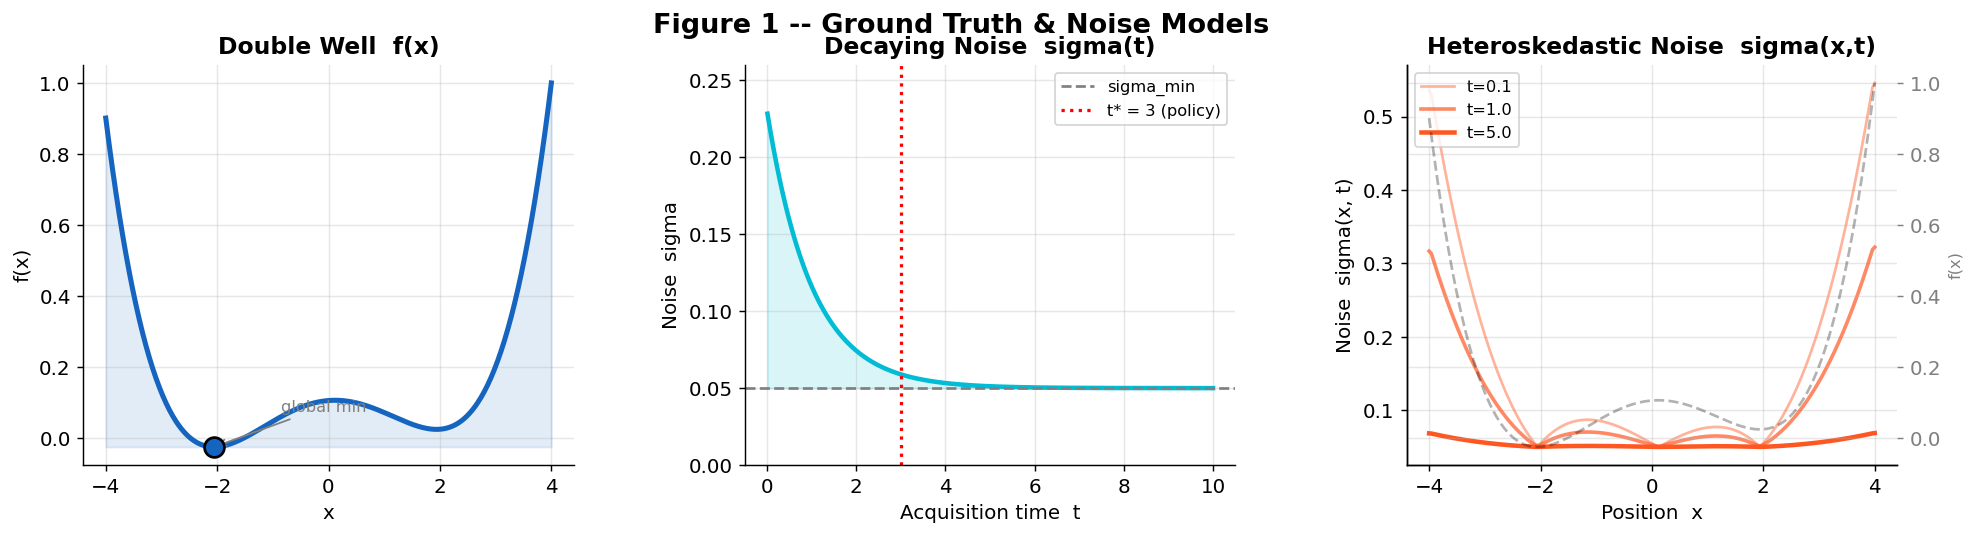

Figure 1 saved.


In [ ]:
# ============================================================
#  FIGURE 1 - Ground Truth & Noise Models Overview
# ============================================================
x_plot = np.linspace(-4, 4, 400)
t_plot = np.linspace(0.01, 10, 300)

fig = plt.figure(figsize=(18, 4))
gs_main = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

ax0 = fig.add_subplot(gs_main[0])
y_dw = double_well(x_plot)
ax0.plot(x_plot, y_dw, '#1565C0', lw=2.8)
ax0.fill_between(x_plot, y_dw, y_dw.min(), alpha=0.12, color='#1565C0')
idx = np.argmin(y_dw)
ax0.scatter(x_plot[idx], y_dw[idx], s=120, color='#1565C0',
            edgecolors='black', linewidths=1.5, zorder=5)
ax0.set_title('Double Well  f(x)', fontweight='bold')
ax0.set_xlabel('x'); ax0.set_ylabel('f(x)')
ax0.annotate('global min', xy=(x_plot[idx], y_dw[idx]),
             xytext=(x_plot[idx]+1.2, y_dw[idx]+0.1),
             arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9, color='gray')

ax1 = fig.add_subplot(gs_main[1])
sig_d = noise_decay_floor(t=t_plot)
ax1.plot(t_plot, sig_d, color=C_DECAY, lw=2.5)
ax1.fill_between(t_plot, sig_d, 0.05, alpha=0.15, color=C_DECAY)
ax1.axhline(0.05, color='gray', ls='--', lw=1.5, label='sigma_min')
ax1.axvline(3.0,  color='red',  ls=':',  lw=1.8, label='t* = 3 (policy)')
ax1.set_title('Decaying Noise  sigma(t)', fontweight='bold')
ax1.set_xlabel('Acquisition time  t'); ax1.set_ylabel('Noise  sigma')
ax1.set_ylim(0, 0.26); ax1.legend()

ax2  = fig.add_subplot(gs_main[2])
ax2r = ax2.twinx()
ax2r.plot(x_plot, y_dw, 'k--', lw=1.5, alpha=0.3, label='f(x)')
ax2r.set_ylabel('f(x)', fontsize=9, color='gray')
ax2r.tick_params(axis='y', colors='gray')
for t_val, alpha, lw in [(0.1, 0.45, 1.5), (1.0, 0.70, 2.0), (5.0, 1.0, 2.5)]:
    s = noise_het(x_plot, np.ones_like(x_plot)*t_val)
    ax2.plot(x_plot, s, color=C_HET, alpha=alpha, lw=lw, label=f't={t_val}')
ax2.set_title('Heteroskedastic Noise  sigma(x,t)', fontweight='bold')
ax2.set_xlabel('Position  x'); ax2.set_ylabel('Noise  sigma(x, t)')
ax2.legend(loc='upper left')

fig.suptitle('Figure 1 -- Ground Truth & Noise Models', fontsize=15, fontweight='bold')
plt.savefig('fig1_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')


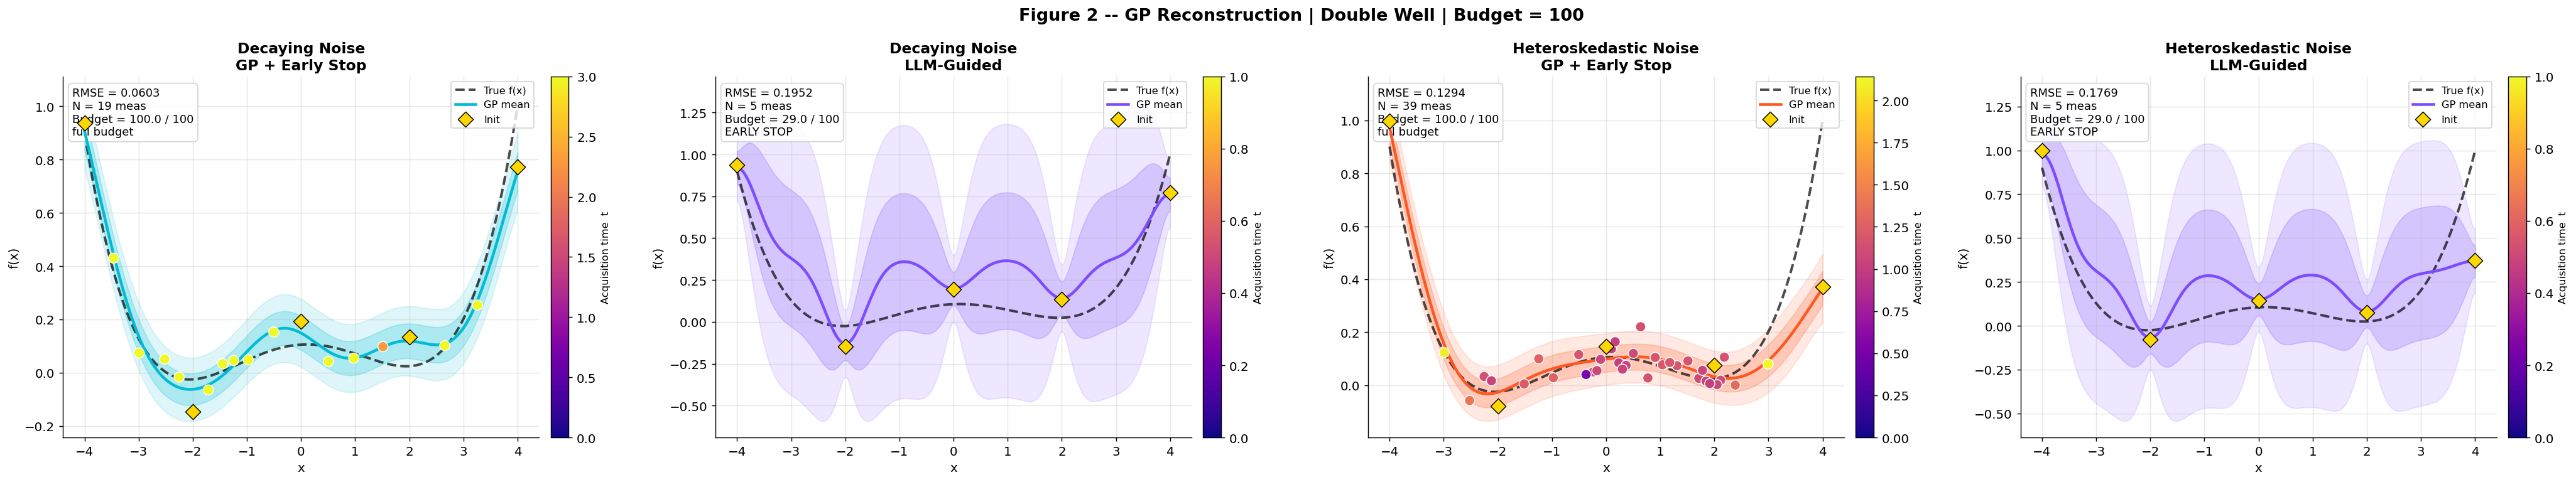

Figure 2 saved.


In [ ]:
# ============================================================
#  FIGURE 2 - GP Reconstruction for each noise type x mode
# ============================================================
available = list(results.keys())
n_cols = len(available)
fig, axes = plt.subplots(1, n_cols, figsize=(8*n_cols, 6))
if n_cols == 1:
    axes = [axes]

for ax, (noise_type, mode) in zip(axes, available):
    res   = results[(noise_type, mode)]
    xg    = res['x_grid']
    gm, gs, tv = res['gp_mean'], res['gp_std'], res['true']
    color = C_LLM if mode == 'llm' else NOISE_COLORS[noise_type]
    mode_label = 'LLM-Guided' if mode == 'llm' else 'GP + Early Stop'

    ax.plot(xg, tv, 'k--', lw=2.2, alpha=0.7, label='True f(x)', zorder=3)
    ax.fill_between(xg, gm-2*gs, gm+2*gs, alpha=0.13, color=color)
    ax.fill_between(xg, gm-gs,   gm+gs,   alpha=0.22, color=color)
    ax.plot(xg, gm, color=color, lw=2.5, label='GP mean', zorder=4)

    sc = ax.scatter(res['x_obs'], res['y_obs'], c=res['t_obs'],
                    cmap='plasma', s=80, zorder=5,
                    edgecolors='white', linewidths=0.8, vmin=0)
    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label('Acquisition time  t', fontsize=9)

    init_idx = [i for i, e in enumerate(res['cost_log']) if e['phase'] == 'init']
    ax.scatter([res['x_obs'][i] for i in init_idx],
               [res['y_obs'][i] for i in init_idx],
               marker='D', s=90, color='gold',
               edgecolors='black', linewidths=0.8, zorder=6, label='Init')

    stop_str = 'EARLY STOP' if res['stopped_early'] else 'full budget'
    ax.text(0.02, 0.97,
            f"RMSE = {res['rmse']:.4f}\nN = {res['n_meas']} meas\n"
            f"Budget = {res['budget_used']:.1f} / 100\n{stop_str}",
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round,pad=0.35', fc='white', alpha=0.9, ec='lightgray'))

    ax.set_title(f"{NOISE_LABELS[noise_type]}\n{mode_label}",
                 fontweight='bold')
    ax.set_xlabel('x'); ax.set_ylabel('f(x)')
    ax.legend(loc='upper right')

fig.suptitle('Figure 2 -- GP Reconstruction | Double Well | Budget = 100',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_gp_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')


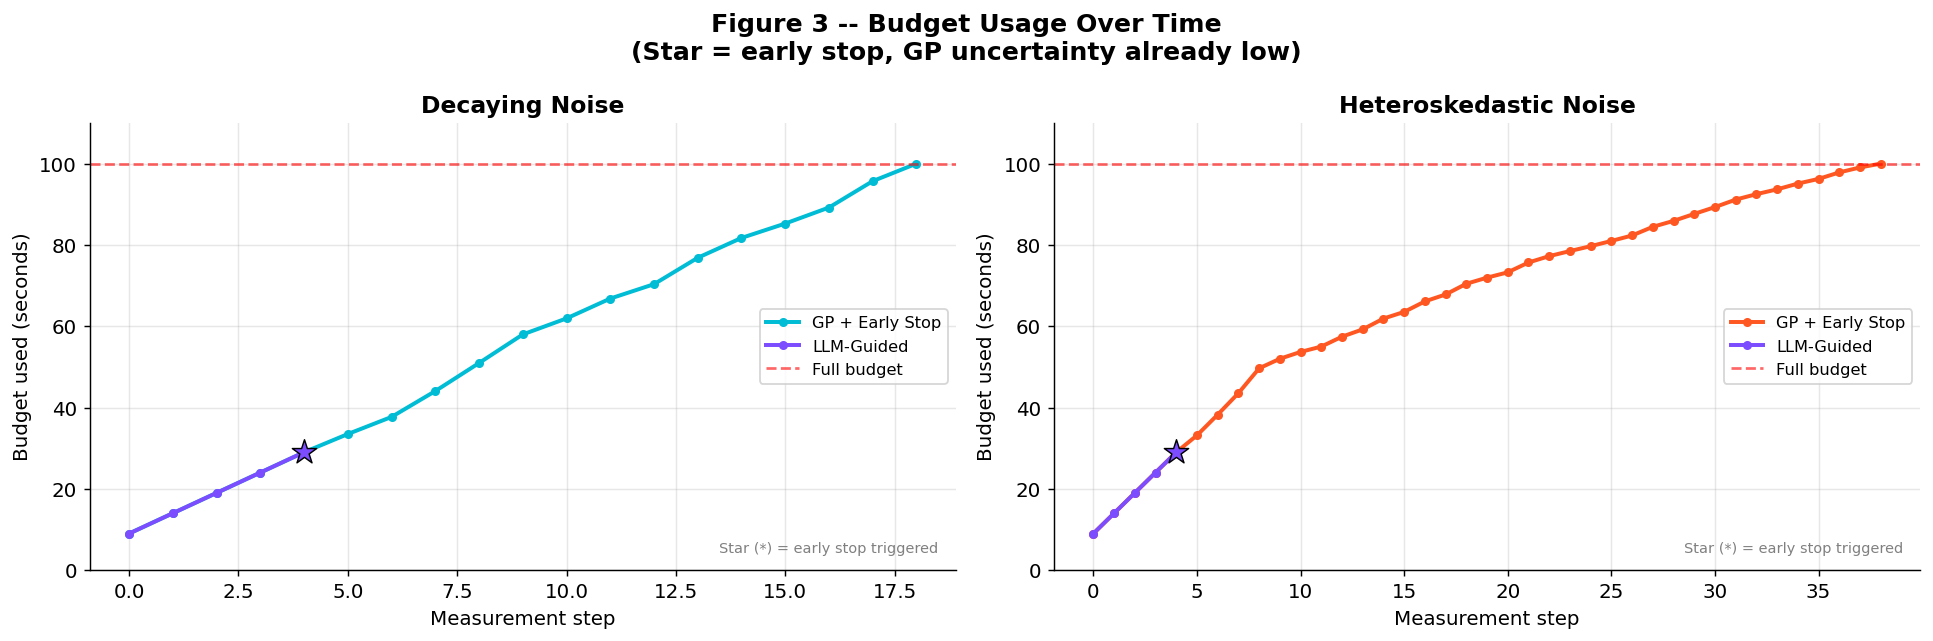

Figure 3 saved.


In [ ]:
# ============================================================
#  FIGURE 3 - Budget Usage: How much budget was actually used?
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, noise_type in zip(axes, NOISE_TYPES):
    color = NOISE_COLORS[noise_type]
    modes_available = [m for (nt, m) in results if nt == noise_type]

    for mode in modes_available:
        res = results[(noise_type, mode)]
        cl  = res['cost_log']
        steps    = [e['step'] for e in cl]
        budg_rem = [e['budget_left'] for e in cl]
        budg_used = [100 - b for b in budg_rem]
        c   = C_LLM if mode == 'llm' else color
        lbl = 'LLM-Guided' if mode == 'llm' else 'GP + Early Stop'
        ax.plot(steps, budg_used, color=c, lw=2.2, marker='o',
                markersize=4, label=lbl)
        # Mark early stop
        if res['stopped_early']:
            ax.scatter([steps[-1]], [budg_used[-1]], s=200,
                       marker='*', color=c, zorder=6,
                       edgecolors='black', linewidths=0.8)

    ax.axhline(100, color='red', ls='--', lw=1.5, alpha=0.6, label='Full budget')
    ax.set_xlabel('Measurement step')
    ax.set_ylabel('Budget used (seconds)')
    ax.set_title(NOISE_LABELS[noise_type], fontweight='bold')
    ax.legend()
    ax.set_ylim(0, 110)

    note = 'Star (*) = early stop triggered'
    ax.text(0.98, 0.04, note, transform=ax.transAxes,
            fontsize=8, color='gray', ha='right')

fig.suptitle('Figure 3 -- Budget Usage Over Time\n'
             '(Star = early stop, GP uncertainty already low)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_budget_usage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')


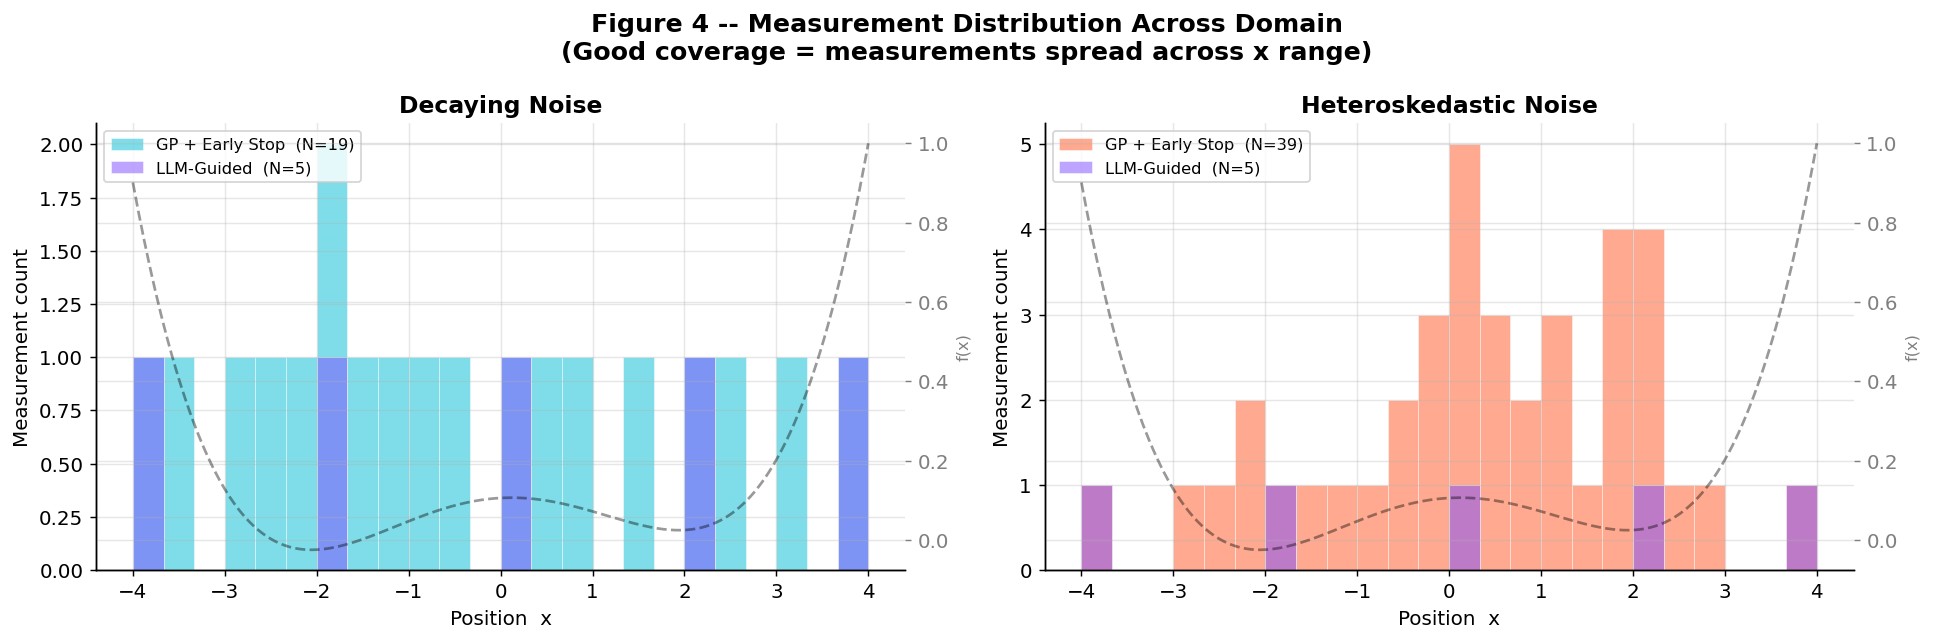

Figure 4 saved.


In [ ]:
# ============================================================
#  FIGURE 4 - Where did we probe?  (histogram of x positions)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, noise_type in zip(axes, NOISE_TYPES):
    color = NOISE_COLORS[noise_type]
    modes_av = [m for (nt, m) in results if nt == noise_type]
    bins = np.linspace(-4, 4, 25)

    for i, mode in enumerate(modes_av):
        res = results[(noise_type, mode)]
        c   = C_LLM if mode == 'llm' else color
        lbl = 'LLM-Guided' if mode == 'llm' else 'GP + Early Stop'
        ax.hist(res['x_obs'], bins=bins, color=c, alpha=0.5,
                label=f"{lbl}  (N={res['n_meas']})",
                edgecolor='white', linewidth=0.5)

    # Overlay true function for reference
    ax2 = ax.twinx()
    x_p = np.linspace(-4, 4, 400)
    ax2.plot(x_p, double_well(x_p), 'k--', lw=1.5, alpha=0.4, label='f(x)')
    ax2.set_ylabel('f(x)', fontsize=9, color='gray')
    ax2.tick_params(axis='y', colors='gray')

    ax.set_xlabel('Position  x')
    ax.set_ylabel('Measurement count')
    ax.set_title(NOISE_LABELS[noise_type], fontweight='bold')
    ax.legend(loc='upper left')

fig.suptitle('Figure 4 -- Measurement Distribution Across Domain\n'
             '(Good coverage = measurements spread across x range)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_measurement_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')


Computing uncertainty histories (may take ~30s)...
Done.


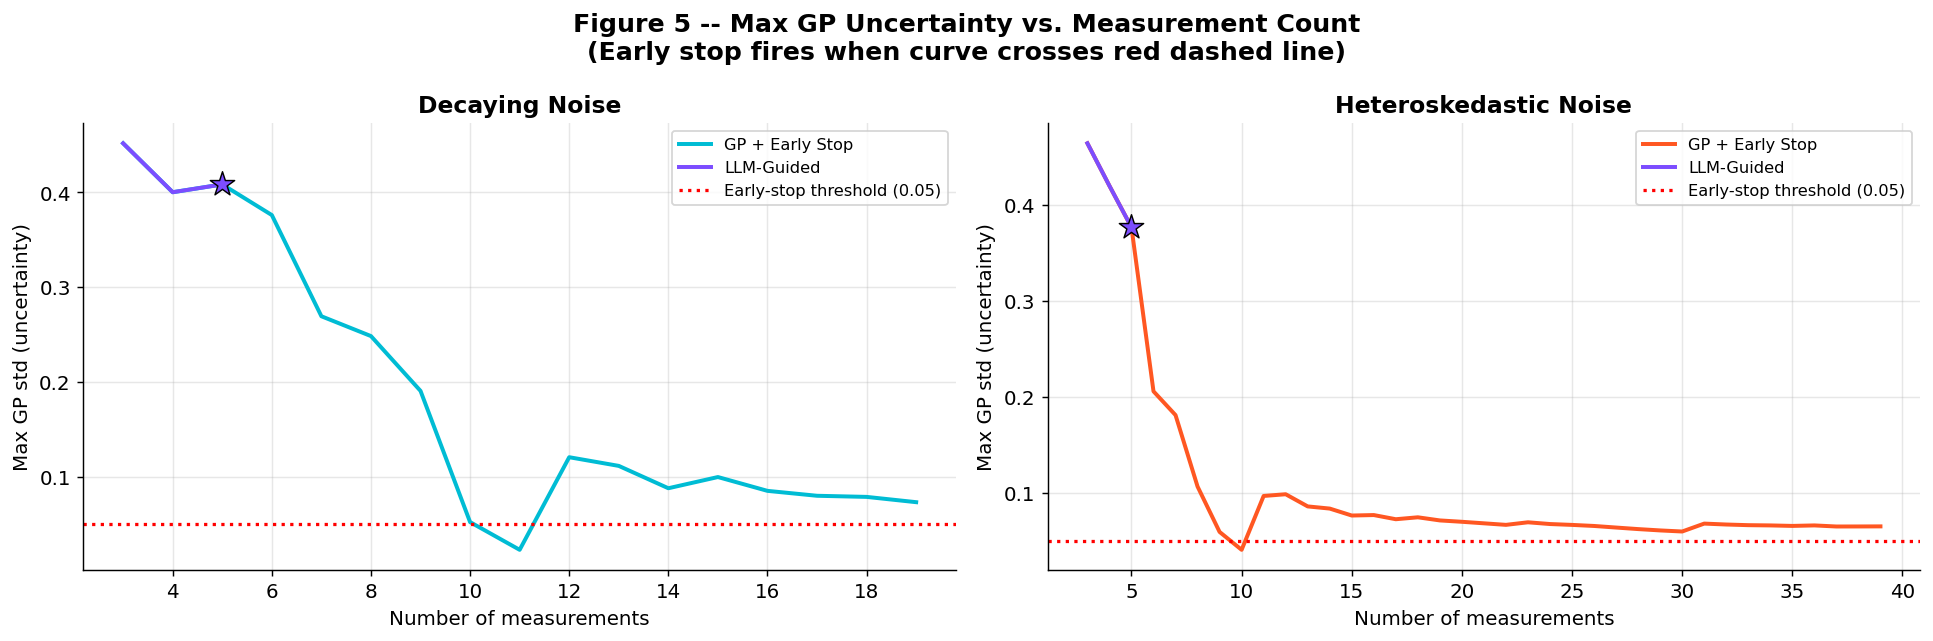

Figure 5 saved.


In [ ]:
# ============================================================
#  FIGURE 5 - Uncertainty curve: how does max GP std drop over steps?
# ============================================================

def compute_std_history(res):
    xa   = res['x_obs']
    ya   = res['y_obs']
    xg   = res['x_grid']
    stds = []
    for n in range(max(3, 1), len(xa)+1):
        try:
            _, gs = gp_predict(xa[:n], ya[:n], xg)
            stds.append(gs.max())
        except Exception:
            stds.append(float('nan'))
    return stds

print('Computing uncertainty histories (may take ~30s)...')
unc_histories = {k: compute_std_history(v) for k, v in results.items()}
print('Done.')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, noise_type in zip(axes, NOISE_TYPES):
    color = NOISE_COLORS[noise_type]
    modes_av = [m for (nt, m) in results if nt == noise_type]

    for mode in modes_av:
        res  = results[(noise_type, mode)]
        hist = unc_histories[(noise_type, mode)]
        c    = C_LLM if mode == 'llm' else color
        lbl  = 'LLM-Guided' if mode == 'llm' else 'GP + Early Stop'
        ns   = list(range(3, len(hist)+3))
        ax.plot(ns, hist, color=c, lw=2.2, label=lbl)
        if res['stopped_early']:
            ax.scatter([ns[-1]], [hist[-1]], s=200, marker='*',
                       color=c, zorder=6, edgecolors='black', lw=0.8)

    ax.axhline(STOP_THRESHOLD, color='red', ls=':', lw=1.8,
               label=f'Early-stop threshold ({STOP_THRESHOLD})')
    ax.set_xlabel('Number of measurements')
    ax.set_ylabel('Max GP std (uncertainty)')
    ax.set_title(NOISE_LABELS[noise_type], fontweight='bold')
    ax.legend()

fig.suptitle('Figure 5 -- Max GP Uncertainty vs. Measurement Count\n'
             '(Early stop fires when curve crosses red dashed line)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_uncertainty_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')


Computing GP evolution snapshots...
Done.


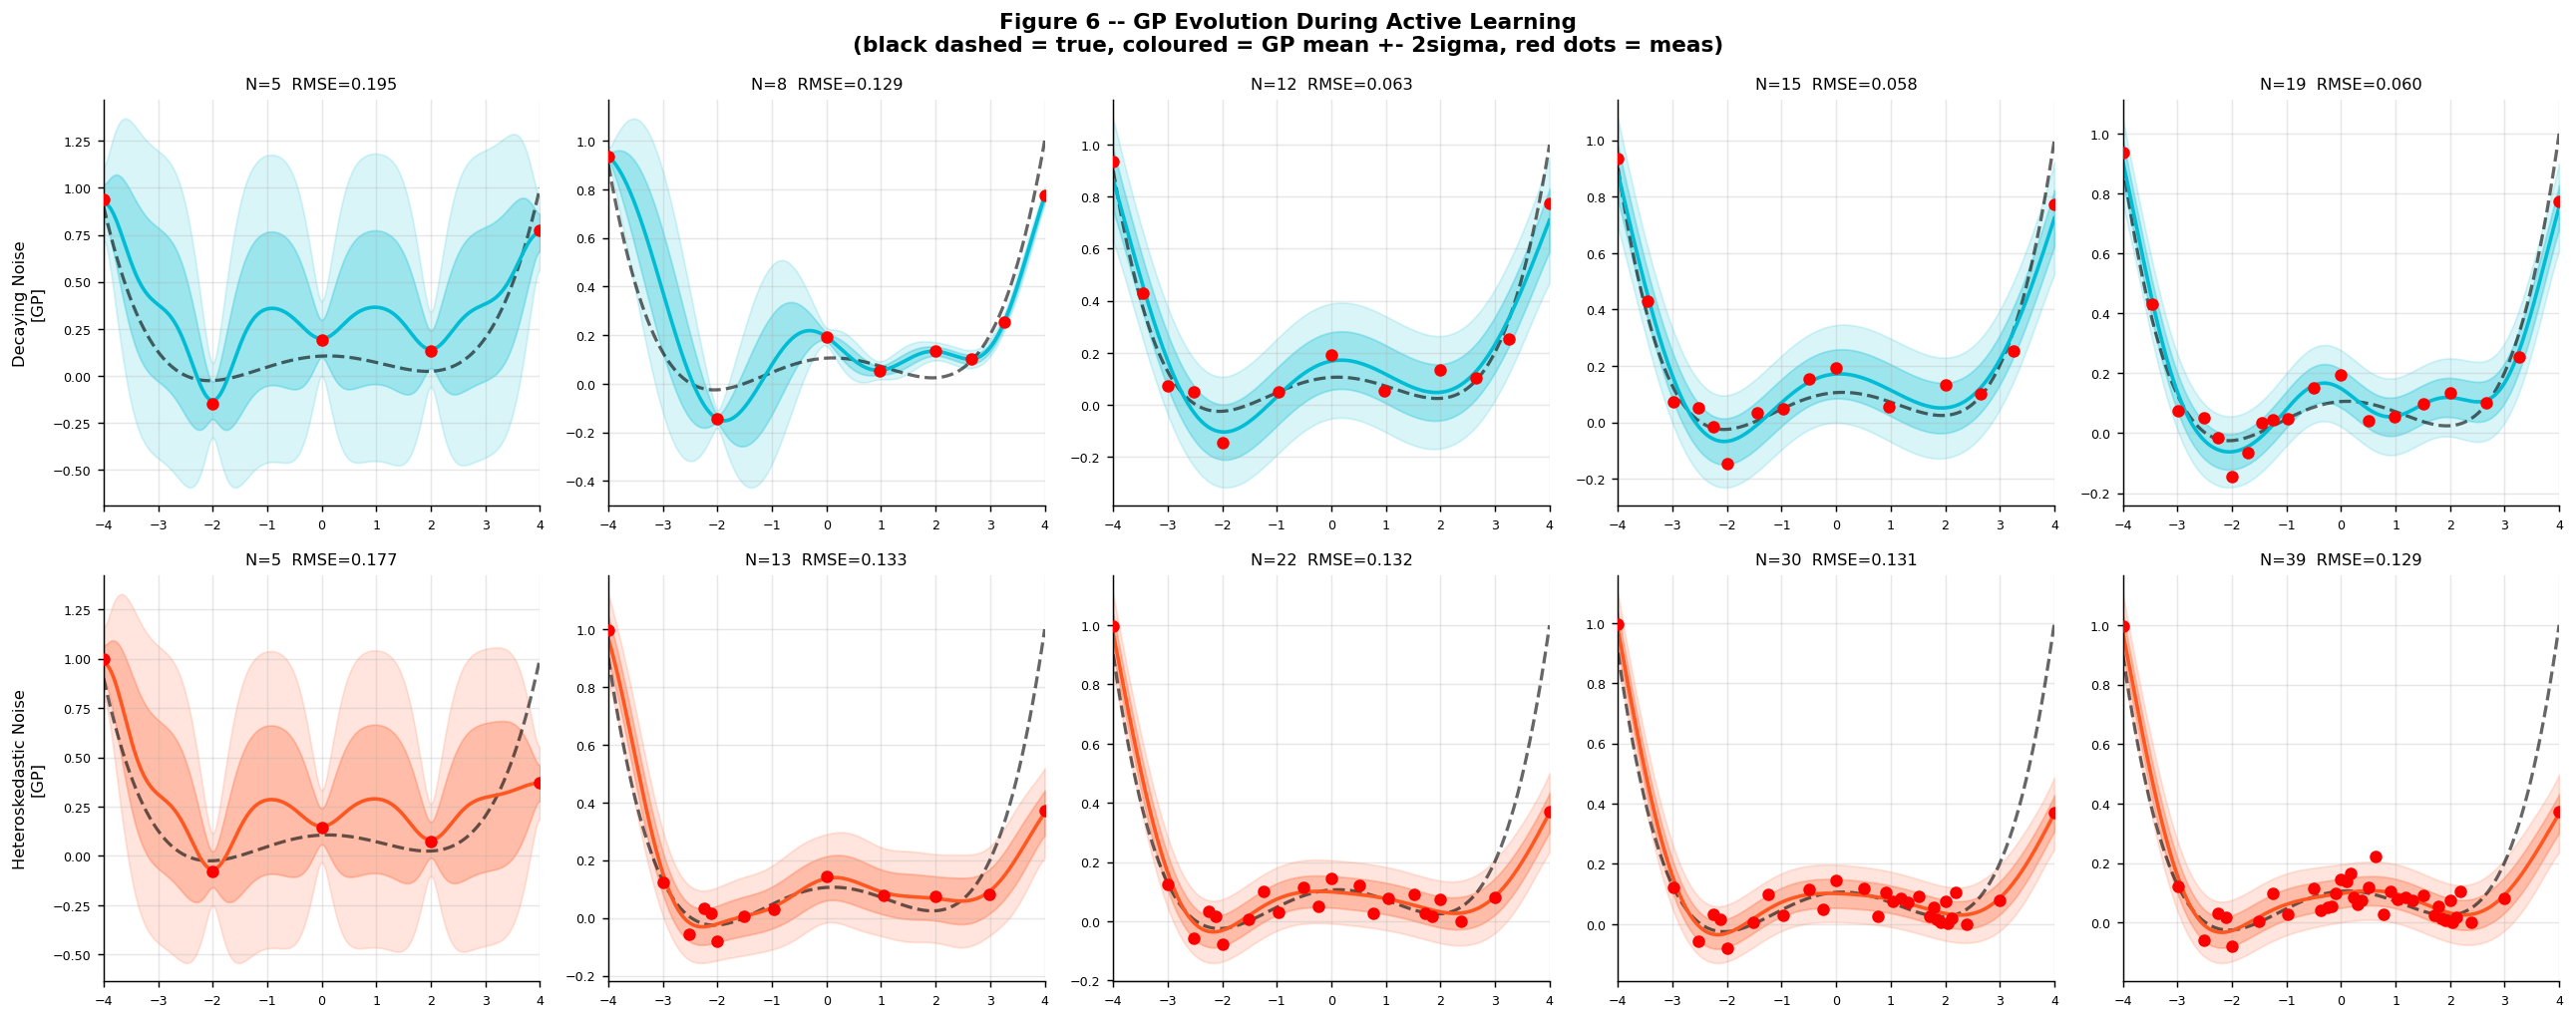

Figure 6 saved.


In [ ]:
# ============================================================
#  FIGURE 6 - GP Evolution During Active Learning
# ============================================================

def collect_snapshots(res, n_snap=5):
    xa, ya = res['x_obs'], res['y_obs']
    xg     = res['x_grid']
    indices = np.linspace(4, len(xa)-1, n_snap, dtype=int)
    snaps   = []
    for i in indices:
        gm, gs = gp_predict(xa[:i+1], ya[:i+1], xg)
        tv     = double_well(xg)
        rmse   = np.sqrt(np.mean((gm - tv)**2))
        snaps.append({'n': i+1, 'gm': gm, 'gs': gs, 'rmse': rmse,
                      'xo': xa[:i+1], 'yo': ya[:i+1]})
    return snaps

print('Computing GP evolution snapshots...')
# Pick one noise type per mode
snap_keys = []
for noise_type in NOISE_TYPES:
    for mode in ['gp', 'llm']:
        if (noise_type, mode) in results:
            snap_keys.append((noise_type, mode))
            break   # one mode per noise type for compactness

all_snaps = {k: collect_snapshots(results[k]) for k in snap_keys}
print('Done.')

n_rows = len(snap_keys)
N_SNAP = 5
fig, axes = plt.subplots(n_rows, N_SNAP, figsize=(4*N_SNAP, 4*n_rows))
if n_rows == 1:
    axes = [axes]

for row_axes, (noise_type, mode) in zip(axes, snap_keys):
    res   = results[(noise_type, mode)]
    color = C_LLM if mode == 'llm' else NOISE_COLORS[noise_type]
    mode_lbl = 'LLM' if mode == 'llm' else 'GP'

    for ax, snap in zip(row_axes, all_snaps[(noise_type, mode)]):
        xg = res['x_grid']
        ax.plot(xg, res['true'], 'k--', lw=1.8, alpha=0.6)
        ax.fill_between(xg, snap['gm']-2*snap['gs'],
                         snap['gm']+2*snap['gs'], alpha=0.15, color=color)
        ax.fill_between(xg, snap['gm']-snap['gs'],
                         snap['gm']+snap['gs'],   alpha=0.28, color=color)
        ax.plot(xg, snap['gm'], color=color, lw=2)
        ax.scatter(snap['xo'], snap['yo'], color='red', s=35, zorder=5)
        ax.set_title(f"N={snap['n']}  RMSE={snap['rmse']:.3f}", fontsize=9)
        ax.set_xlim(-4, 4)
        ax.tick_params(labelsize=7)

    row_axes[0].set_ylabel(
        f"{NOISE_LABELS[noise_type]}\n[{mode_lbl}]", fontsize=9)

fig.suptitle('Figure 6 -- GP Evolution During Active Learning\n'
             '(black dashed = true, coloured = GP mean +- 2sigma, red dots = meas)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_gp_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')


In [ ]:
# ============================================================
#  FIGURE 7 - LLM Reasoning Log  (skipped if LLM not available)
# ============================================================

llm_keys = [(nt, m) for (nt, m) in results if m == 'llm']

if not llm_keys:
    print('No LLM results available -- skipping Figure 7.')
    print('To enable: add your Gemini API key in Cell 3 and re-run.')
else:
    for (noise_type, mode) in llm_keys:
        res = results[(noise_type, mode)]
        log = res['llm_log']
        if not log:
            print(f'No LLM reasoning log for {noise_type}')
            continue

        n_log = len(log)
        fig, ax = plt.subplots(figsize=(14, max(4, 0.55 * n_log + 2)))
        ax.axis('off')

        header = ['Step', 'x_next', 't', 'Reasoning']
        rows   = [[str(e['step']),
                   f"{e['x']:.2f}",
                   f"{e['t']:.2f}",
                   e['reasoning'][:90] + ('...' if len(e['reasoning']) > 90 else '')]
                  for e in log]

        col_widths = [0.06, 0.08, 0.06, 0.75]
        tbl = ax.table(
            cellText=rows,
            colLabels=header,
            colWidths=col_widths,
            loc='center', cellLoc='left')
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        tbl.scale(1, 1.5)

        for (r, c), cell in tbl.get_celld().items():
            if r == 0:
                cell.set_facecolor('#4A4A8A')
                cell.set_text_props(color='white', fontweight='bold')
            elif r % 2 == 0:
                cell.set_facecolor('#F0EEF8')

        ax.set_title(
            f'Figure 7 -- Gemini LLM Reasoning Log  |  {NOISE_LABELS[noise_type]}\n'
            f'Each row = one step where LLM chose where to measure and why.',
            fontsize=12, fontweight='bold', pad=15)

        plt.tight_layout()
        plt.savefig(f'fig7_llm_reasoning_{noise_type}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
        print(f'Figure 7 saved for {noise_type}.')


No LLM reasoning log for decay
No LLM reasoning log for heteroskedastic


In [ ]:
# ============================================================
#  SUMMARY TABLE
# ============================================================
print()
print('=' * 80)
print(f"{'Noise':22} {'Mode':15} {'N':>5} {'Budget':>12} {'Budget%':>8}"
      f" {'RMSE':>8} {'Early?':>8}")
print('-' * 80)

for (noise_type, mode), res in sorted(results.items()):
    label   = NOISE_LABELS[noise_type]
    mode_lbl = 'LLM-Guided' if mode == 'llm' else 'GP+EarlyStop'
    pct     = res['budget_used'] / BUDGET * 100
    stop    = 'YES' if res['stopped_early'] else 'no'
    print(f"{label:22} {mode_lbl:15} {res['n_meas']:5d}"
          f" {res['budget_used']:>9.1f}/{BUDGET} {pct:>7.1f}%"
          f" {res['rmse']:>8.4f} {stop:>8}")

print('=' * 80)
print()
print('KEY INSIGHT: Early stopping saves unused budget when the GP')
print('is already confident (max std < threshold). The saved budget')
print('could be reallocated to a second run or a different region.')
if any(m == 'llm' for (_, m) in results):
    print()
    print('LLM INSIGHT: Gemini provides human-readable reasoning for each')
    print('acquisition decision, making the process interpretable and')
    print('potentially catching domain-specific knowledge gaps.')



Noise                  Mode                N       Budget  Budget%     RMSE   Early?
--------------------------------------------------------------------------------
Decaying Noise         GP+EarlyStop       19     100.0/100   100.0%   0.0603       no
Decaying Noise         LLM-Guided          5      29.0/100    29.0%   0.1952      YES
Heteroskedastic Noise  GP+EarlyStop       39     100.0/100   100.0%   0.1294       no
Heteroskedastic Noise  LLM-Guided          5      29.0/100    29.0%   0.1769      YES

KEY INSIGHT: Early stopping saves unused budget when the GP
is already confident (max std < threshold). The saved budget
could be reallocated to a second run or a different region.

LLM INSIGHT: Gemini provides human-readable reasoning for each
acquisition decision, making the process interpretable and
potentially catching domain-specific knowledge gaps.
